In [1]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np


# Librerías de visualización
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) 


# Lectura de los datos
#-----------------------------------------------------------------------
df_flight = pd.read_csv('Customer Flight Activity.csv ')
df_loyalty = pd.read_csv('Customer Loyalty History.csv ')

### **Fase 1: Exploracion y Limpieza**
1. Exploración Inicial:
    - Realiza una exploración inicial de los datos para identificar posibles problemas, como valores nulos, atípicos o datos faltantes en las columnas relevantes.
    - Utiliza funciones de Pandas para obtener información sobre la estructura de los datos, la presencia de valores nulos y estadísticas básicas de las columnas involucradas.
    - Une los dos conjuntos de datos de la forma más eficiente.

2. Limpieza de Datos:
    - Elimina o trata los valores nulos, si los hay, en las columnas clave para asegurar que los datos estén completos.
    - Verifica la consistencia y corrección de los datos para asegurarte de que los datos se presenten de forma coherente.
    - Realiza cualquier ajuste o conversión necesaria en las columnas (por ejemplo, cambiar tipos de datos) para garantizar la adecuación de los datos para el análisis estadístico.

*1.1 y 1.2 – Exploración inicial: estructura, nulos y estadísticas básicas*

*Empiezo creando la función `eda_basico` y la aplico a los dos DataFrames.*
*Esto cubre los puntos 1.1 y 1.2 del enunciado: identificar problemas (nulos, atípicos, datos faltantes)y obtener información sobre la estructura del dataset.*

In [2]:
def eda_basico(df): 

    print("🔹 HEAD")
    display(df.head()) #primeras 5 filas para ver la estructura general
    
    print("\n🔹 TAIL")
    display(df.tail()) #últimas 5 filas para detectar si hay filas vacías o basura
    
    print("\n🔹 SAMPLE")
    display(df.sample()) # fila aleatoria para tener una visión más representativa del interior
    
    print("\n🔹 INFO")
    print(df.info()) # tipos de datos y valores no nulos por columna de un vistazo
   
    print("\n🔹 Nombres de las columnas:")
    display(df.columns) # para detectar espacios, mayúsculas o caracteres raros en los nombres

    print("\n🔹 Número de filas y columnas:")
    display(df.shape) # (filas, columnas) para conocer la escala del dataset

    print("\n🔹 DESCRIBE (numéricas)")
    display(df.describe().round(2)) # count, media, std, min, max y percentiles de columnas numéricas
    
    print("\n🔹 DESCRIBE (categóricas)")
    cat_cols = df.select_dtypes(include="str").columns
    if len(cat_cols) > 0:
        display(df.describe(include="str"))
    else:
        print("No hay columnas categóricas")    # frecuencia y valores únicos de columnas de texto
 
    print("\n🔹 DUPLICADOS")
    print(f"Filas duplicadas: {df.duplicated().sum()}") # filas exactamente iguales en todas sus columnas
    
    print("\n🔹 VALUE COUNTS (columnas categóricas)")
    cat_cols = df.select_dtypes(include="str").columns
    for col in cat_cols:
        print(f"\n{col}")
        display(df[col].value_counts(dropna=False)) # dropna=False para que los NaN también cuenten

    print("\n🔹 VALORES NULOS")
    print(((df.isnull().sum() / df.shape[0]) * 100).round(2)) # en porcentaje porque es más visible para decidir cómo tratar cada columna 

In [3]:
eda_basico(df_loyalty)

🔹 HEAD


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN



🔹 TAIL


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0



🔹 SAMPLE


...


Loyalty Card


Loyalty Card
Star      7637
Nova      5671
Aurora    3429
Name: count, dtype: int64


Enrollment Type


Enrollment Type
Standard          15766
2018 Promotion      971
Name: count, dtype: int64


🔹 VALORES NULOS
Loyalty Number         0.00
Country                0.00
Province               0.00
City                   0.00
Postal Code            0.00
Gender                 0.00
Education              0.00
Salary                25.32
Marital Status         0.00
Loyalty Card           0.00
CLV                    0.00
Enrollment Type        0.00
Enrollment Year        0.00
Enrollment Month       0.00
Cancellation Year     87.65
Cancellation Month    87.65
dtype: float64


In [4]:
eda_basico(df_flight)

🔹 HEAD


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0



🔹 TAIL


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
405619,999902,2018,12,0,0,0,0,0.0,0,0
405620,999911,2018,12,0,0,0,0,0.0,0,0
405621,999940,2018,12,3,0,3,1233,123.0,0,0
405622,999982,2018,12,0,0,0,0,0.0,0,0
405623,999986,2018,12,0,0,0,0,0.0,0,0



🔹 SAMPLE


...


🔹 Número de filas y columnas:


(405624, 10)


🔹 DESCRIBE (numéricas)


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
count,405624.00,405624.0,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00
mean,550037.87,2017.5,6.50,4.12,1.03,5.15,1208.88,123.69,30.70,2.48
std,258935.29,0.5,3.45,5.23,2.08,6.52,1433.16,146.60,125.49,10.15
min,100018.00,2017.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,326961.00,2017.0,3.75,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,550834.00,2017.5,6.50,1.00,0.00,1.00,488.00,50.00,0.00,0.00
75%,772194.00,2018.0,9.25,8.00,1.00,10.00,2336.00,239.00,0.00,0.00
max,999986.00,2018.0,12.00,21.00,11.00,32.00,6293.00,676.50,876.00,71.00



🔹 DESCRIBE (categóricas)
No hay columnas categóricas

🔹 DUPLICADOS
Filas duplicadas: 1864

🔹 VALUE COUNTS (columnas categóricas)

🔹 VALORES NULOS
Loyalty Number                 0.0
Year                           0.0
Month                          0.0
Flights Booked                 0.0
Flights with Companions        0.0
Total Flights                  0.0
Distance                       0.0
Points Accumulated             0.0
Points Redeemed                0.0
Dollar Cost Points Redeemed    0.0
dtype: float64


*1.3 – Unión de los dos conjuntos de datos*

*Ambos DataFrames comparten la columna `Loyalty Number`, que es la clave de unión.*
*Usamos `merge` con `how='left'` partiendo de `df_flight` para conservar todos los registros de actividad y enriquecer cada fila con el perfil del cliente correspondiente.*

In [5]:
df = pd.merge(df_flight, df_loyalty, on="Loyalty Number", how="left")

print(f"df_flight:  {df_flight.shape}")
print(f"df_loyalty: {df_loyalty.shape}")
print(f"df merged:  {df.shape}")

df_flight:  (405624, 10)
df_loyalty: (16737, 16)
df merged:  (405624, 25)


In [6]:
df.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,3,NaN,NaN
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,NaN,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN


*2.1 – Tratamiento de valores nulos*

*Primero revisamos el porcentaje de nulos en el DataFrame unido.*

In [7]:
print(((df.isnull().sum() / df.shape[0]) * 100).round(2))

Loyalty Number                  0.00
Year                            0.00
Month                           0.00
Flights Booked                  0.00
Flights with Companions         0.00
Total Flights                   0.00
Distance                        0.00
Points Accumulated              0.00
Points Redeemed                 0.00
Dollar Cost Points Redeemed     0.00
Country                         0.00
Province                        0.00
City                            0.00
Postal Code                     0.00
Gender                          0.00
Education                       0.00
Salary                         25.31
Marital Status                  0.00
Loyalty Card                    0.00
CLV                             0.00
Enrollment Type                 0.00
Enrollment Year                 0.00
Enrollment Month                0.00
Cancellation Year              87.66
Cancellation Month             87.66
dtype: float64


`Cancellation Year` y `Cancellation Month`: Son nulos **lógicos**, los clientes siguen activos y no existe fecha de cancelación, por lo que no corresponde imputarlos

`Salary`: tiene un 25% de nulos y valores erróneos (en el .describe() se encontró un mínimo negativo), primero se convierte a NaN y luego se imputa con la mediana.

In [8]:
# Valores negativos en Salary → imposibles, los convertimos a NaN
df["Salary"] = df["Salary"].apply(lambda x: x if x >= 0 else np.nan)

print(f"Nulos en Salary tras limpiar negativos: {df['Salary'].isnull().sum()}")

# Imputamos Salary con la mediana
mediana_salary = df["Salary"].median()
df["Salary"] = df["Salary"].fillna(mediana_salary)

print(f"Mediana usada para imputar: {mediana_salary}")
print(f"Nulos en Salary tras imputar: {df['Salary'].isnull().sum()}")

Nulos en Salary tras limpiar negativos: 103152
Mediana usada para imputar: 73523.0
Nulos en Salary tras imputar: 0


In [9]:
# Verificamos que no queden nulos relevantes
print(df.isnull().sum())

Loyalty Number                      0
Year                                0
Month                               0
Flights Booked                      0
Flights with Companions             0
Total Flights                       0
Distance                            0
Points Accumulated                  0
Points Redeemed                     0
Dollar Cost Points Redeemed         0
Country                             0
Province                            0
City                                0
Postal Code                         0
Gender                              0
Education                           0
Salary                              0
Marital Status                      0
Loyalty Card                        0
CLV                                 0
Enrollment Type                     0
Enrollment Year                     0
Enrollment Month                    0
Cancellation Year              355560
Cancellation Month             355560
dtype: int64


*2.2 – Consistencia y corrección de los datos*:

*Revisamos que los valores de las columnas categóricas sean coherentes: sin mezclas de mayúsculas/minúsculas, sin espacios extra, sin typos.*

In [10]:
columnas_str = df.select_dtypes(include="str").columns

for col in columnas_str:
    print(f"\n{col}")
    print(df[col].unique())


Country
<StringArray>
['Canada']
Length: 1, dtype: str

Province
<StringArray>
[             'Alberta',              'Ontario',     'British Columbia',
         'Saskatchewan',               'Quebec',         'Newfoundland',
             'Manitoba',        'New Brunswick',          'Nova Scotia',
 'Prince Edward Island',                'Yukon']
Length: 11, dtype: str

City
<StringArray>
[      'Edmonton',        'Toronto',   'Dawson Creek',      'Vancouver',
         'Regina',       'Montreal',        'Sudbury',    'Quebec City',
    'Peace River',     'St. John's',      'Tremblant',         'Ottawa',
        'Trenton',       'Winnipeg',    'Thunder Bay', 'West Vancouver',
    'Fredericton',         'London',        'Halifax',        'Moncton',
          'Banff',       'Kingston',       'Whistler',  'Charlottetown',
           'Hull',       'Victoria',        'Calgary',        'Kelowna',
     'Whitehorse']
Length: 29, dtype: str

Postal Code
<StringArray>
['T9G 1W3', 'M1R 4K3', 'U5I 4

*Los datos de texto vienen consistentes desde el CSV, no se aprecian errores tipográficos, mezclas de mayúsculas/minúsculas ni espacios extra. No es necesario aplicar ninguna transformación.*

*2.3 Conversion de tipos de datos:*

In [11]:
print(df.dtypes)

Loyalty Number                   int64
Year                             int64
Month                            int64
Flights Booked                   int64
Flights with Companions          int64
Total Flights                    int64
Distance                         int64
Points Accumulated             float64
Points Redeemed                  int64
Dollar Cost Points Redeemed      int64
Country                            str
Province                           str
City                               str
Postal Code                        str
Gender                             str
Education                          str
Salary                         float64
Marital Status                     str
Loyalty Card                       str
CLV                            float64
Enrollment Type                    str
Enrollment Year                  int64
Enrollment Month                 int64
Cancellation Year              float64
Cancellation Month             float64
dtype: object


*observaciones:*

- *`Points accumulated` es el unico float cuando todos los demás contadores similares son int64, investigo si son decimales reales o no, y si no lo son lo cambio a int64*
- *`Cancellation Year` y `Cancellation Month` son float64 (por los Nan) lo cambio a Int64  que sí admite Nan.*

In [ ]:
print(df["Points Accumulated"].unique()[:20])  #no son decimales reales, los puedo pasar a int64

[152. 203. 120.   0.  60. 424. 114. 326. 234. 123. 312. 229. 277. 294.
 110. 133. 208. 339.  65. 151.]


In [13]:
# Cancellation Year y Month → Int64 (entero nullable que admite NaN)
df["Cancellation Year"]  = df["Cancellation Year"].astype("Int64")
df["Cancellation Month"] = df["Cancellation Month"].astype("Int64")

# Points Accumulated → int64 (no tiene decimales reales)
df["Points Accumulated"] = df["Points Accumulated"].astype("int64")

# Verificamos
print(df.dtypes)

Loyalty Number                   int64
Year                             int64
Month                            int64
Flights Booked                   int64
Flights with Companions          int64
Total Flights                    int64
Distance                         int64
Points Accumulated               int64
Points Redeemed                  int64
Dollar Cost Points Redeemed      int64
Country                            str
Province                           str
City                               str
Postal Code                        str
Gender                             str
Education                          str
Salary                         float64
Marital Status                     str
Loyalty Card                       str
CLV                            float64
Enrollment Type                    str
Enrollment Year                  int64
Enrollment Month                 int64
Cancellation Year                Int64
Cancellation Month               Int64
dtype: object


### **Fase 2: Análisis Estadístico**
1. Análisis de variables numéricas:
    - Estadísticas descriptivas (media, mediana, moda, desviación estándar, etc.) de las variables numéricas relevantes.
    - Identificación de valores atípicos en las variables numéricas.
    - Análisis de correlación entre variables numéricas.
2. Análisis de variables categóricas:
    - Distribución de frecuencias de las variables categóricas relevantes.

En todos los ejercicios, no te quedes solo en el “número”: añade siempre una breve interpretación en
lenguaje natural, como lo haría un analista al presentar resultados a un equipo no técnico.

In [ ]:
df.describe().round(2) #identifico las variables numéricas relevantes para el análisis estadístico descriptivo

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Salary,CLV,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
count,405624.00,405624.0,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00,50064.0,50064.0
mean,550037.87,2017.5,6.50,4.12,1.03,5.15,1208.88,123.67,30.70,2.48,77943.50,7991.98,2015.25,6.67,2016.5,6.97
std,258935.29,0.5,3.45,5.23,2.08,6.52,1433.16,146.58,125.49,10.15,30087.68,6863.66,1.98,3.40,1.38,3.45
min,100018.00,2017.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,15609.00,1898.01,2012.00,1.00,2013.0,1.0
25%,326961.00,2017.0,3.75,0.00,0.00,0.00,0.00,0.00,0.00,0.00,63991.00,3985.32,2014.00,4.00,2016.0,4.0
50%,550834.00,2017.5,6.50,1.00,0.00,1.00,488.00,50.00,0.00,0.00,73523.00,5776.34,2015.00,7.00,2017.0,7.0
75%,772194.00,2018.0,9.25,8.00,1.00,10.00,2336.00,239.00,0.00,0.00,82940.00,8936.82,2017.00,10.00,2018.0,10.0
max,999986.00,2018.0,12.00,21.00,11.00,32.00,6293.00,676.00,876.00,71.00,407228.00,83325.38,2018.00,12.00,2018.0,12.0


*Selecciono las variables numéricas con sentido estadístico y descarto: Loyalty Number (identificador), Year, Month, Enrollment Year/Month, Cancellation Year/Month (son fechas)*

In [ ]:
variables_numericas = ['Flights Booked', 'Flights with Companions', 'Total Flights', 'Distance', 'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed', 'Salary', 'CLV']

# Recorremos cada variable y calculamos sus estadísticas básicas
# Usamos :.2f para redondear a 2 decimales en la presentación — no afecta a los datos reales
for var in variables_numericas:
    print(f"\n🔹 {var}")
    print(f"Media: {df[var].mean():.2f}")                        # promedio — sensible a outliers
    print(f"Mediana: {df[var].median():.2f}")                    # valor central — más robusta ante outliers
    print(f"Moda: {df[var].mode()[0]:.2f}")                      # valor más frecuente — mode() devuelve una Serie, [0] para coger el primer valor
    print(f"Desviación estándar: {df[var].std():.2f}")           # dispersión respecto a la media
    print(f"Valor mínimo: {df[var].min()}")
    print(f"Valor máximo: {df[var].max()}")

***
**Conclusiones – Estadísticas descriptivas:**

- **Flights Booked, Flights with Companions, Total Flights y Distance**: en todas estas variables 
la moda es 0 y la mediana es muy baja comparada con la media, lo que indica que la mayoría de 
clientes tiene poca actividad de vuelo. Un grupo reducido de clientes muy activos es el que 
arrastra la media hacia arriba.

- **Points Accumulated, Points Redeemed y Dollar Cost Points Redeemed**: la mayoría de clientes 
acumula pocos puntos (mediana 50, moda 0) y además tampoco los canjea (mediana y moda 0 en ambos). 
Esto sugiere que el programa de puntos no está siendo aprovechado por la mayor parte de los clientes.

- **Salary**: la media (77.943) está por encima de la mediana (73.523), con un máximo de 407.228. 
Hay clientes con salarios muy altos que elevan la media, aunque la mayoría se concentra alrededor 
de 73.523.

- **CLV (Customer Lifetime Value)**: mide cuánto dinero aporta cada cliente a la aerolínea a lo 
largo del tiempo. La media (7.991) es bastante superior a la mediana (5.776), lo que indica que 
la mayoría de clientes generan ingresos moderados, pero hay una minoría de clientes muy rentables 
que elevan el promedio general.
***

*1.2 identificacion de valores atípicos*

*Uso dos enfoques complementarios:* 

- *Boxplot: visualmente muestra donde están los outliers (puntos fuera de los bigotes)*
- *Método IQR : Cuantifica exactamente cuantos outliers hay y cuales son* 

In [ ]:
# Creamos un BOXPLOT por cada variable numérica relevante
# con subplots puedo verlos todos juntos y así poder compararlos
fig, axes = plt.subplots(3, 3, figsize=(15, 12)) # figsize controla el tamaño total de la figura en pulgadas
axes = axes.flatten() # # plt.subplots devuelve una matriz 3x3, con .flatten() convertimos la matriz de ejes en una lista para iterar fácilmente

for i, var in enumerate(variables_numericas):
    axes[i].boxplot(df[var].dropna()) # dropna() para ignorar nulos si los hubiera (no hay, pero es buen práctica)
    axes[i].set_title(var)
    axes[i].set_ylabel("Valor")

plt.suptitle("Boxplots – Detección de valores atípicos", fontsize=14)
plt.tight_layout()  #ajusta el espaciado para que no se solapen los subplots
plt.show()

In [ ]:
#Método IQR (Rango Intercuartílico) para detectar outliers

for var in variables_numericas:
    Q1  = df[var].quantile(0.25)
    Q3  = df[var].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[var] < limite_inferior) | (df[var] > limite_superior)] #selecciono las filas que caen fuera de los límites 
        
    print(f"\n🔹 {var}")
    print(f"  Límite inferior: {limite_inferior:.2f} | Límite superior: {limite_superior:.2f}")
    print(f"  Outliers: {len(outliers)} ({(len(outliers)/len(df)*100):.2f}%)")

***
**Conclusiones – Valores atípicos:**

- **Flights Booked, Total Flights y Distance**: tienen muy pocos outliers (menos del 0.5%), correspondientes a clientes con una actividad de vuelo muy superior a la media. No son preocupantes.

- **Flights with Companions**: tiene un 17.64% de outliers porque el límite superior es 2.5 — cualquier cliente que viaje con más de 2 acompañantes ya se considera atípico. Es un porcentaje alto pero coherente con que la mayoría de clientes viaja solo (moda 0).

- **Points Redeemed y Dollar Cost Points Redeemed**: el método IQR no es adecuado aquí. Como la mayoría de valores son 0, Q1 y Q3 son ambos 0, lo que hace que IQR = 0 y cualquier valor distinto de 0 se marque como outlier. Los boxplots confirman visualmente que sí hay valores extremos, pero el porcentaje del IQR no es interpretable en este caso.

- **Salary**: un 5.14% de outliers por arriba, correspondientes a clientes con salarios muy altos (hasta 407.228). Son datos reales, no errores.

- **CLV**: un 8.92% de outliers, clientes que generan un valor muy alto para la aerolínea. Igual que con Salary, son datos reales que forman parte del negocio.

En ningún caso eliminamos estos outliers — son clientes reales con comportamientos extremos que forman parte del análisis.
***

*1.3 Análisis de correlación entre variables numéricas*

*La correlación mide la relación entre dos variables numéricas:*
- *Valor cercano a **1** → correlación positiva fuerte (cuando una sube, la otra también)*
- *Valor cercano a **-1** → correlación negativa fuerte (cuando una sube, la otra baja)*
- *Valor cercano a **0** → no hay relación lineal entre ellas*

*Usamos un **heatmap** para visualizar todas las correlaciones a la vez.*

In [ ]:
correlacion = df[variables_numericas].corr() # .corr() calcula la matriz de correlación de Pearson entre todas las columnas numéricas seleccionadas

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)             # Visualizamos con un heatmap
ax.set_title("Matriz de correlación – Variables numéricas")                         # annot=True → muestra los valores numéricos dentro de cada celda
plt.tight_layout()                                                                  # fmt=".2f" → redondea a 2 decimales
plt.show()                                                                          # cmap="coolwarm" → azul para correlaciones negativas, rojo para positivas

***
**Conclusiones – Correlación:**

- **Flights Booked, Total Flights, Distance y Points Accumulated** forman un grupo con correlaciones muy altas entre sí. La cadena lógica es clara: más vuelos reservados → más 
vuelos totales → más distancia → más puntos acumulados (0.99 con Distance), ya que los puntos se calculan directamente en base a la distancia volada.

- **Points Redeemed y Dollar Cost Points Redeemed** tienen correlación perfecta (1.00) porque son la misma variable expresada de dos formas: una en puntos y otra en su equivalente en dólares.

- **Points Redeemed correlaciona más con Flights with Companions (0.33) que con Flights Booked (0.19)**, lo que sugiere que los clientes que viajan acompañados tienden a canjear más puntos, posiblemente para obtener beneficios para el grupo.

- **Salary y CLV tienen correlación cercana a 0 con las variables de vuelo**, lo que indica que el salario o el valor del cliente no determinan su actividad de vuelo. Más llamativo aún: Salary y CLV tienen una correlación ligeramente negativa (-0.02) entre sí, lo que sugiere que los clientes con salarios más altos no son necesariamente los más rentables para la aerolínea.

- **Acumular puntos no implica canjearlos**: Points Accumulated y Points Redeemed tienen una correlación baja (0.22), lo que refuerza la conclusión de las estadísticas descriptivas: la mayoría de clientes acumula puntos pero no los canjea.
***

*2. Análisis de variables categóricas: Distribución de frecuencias de las variables categóricas relevantes.*

In [ ]:
df.describe(include = str) #identifico las variables categóricas relevantes para el análisis estadístico descriptivo

,Country,Province,City,Postal Code,Gender,Education,Marital Status,Loyalty Card,Enrollment Type
count,405624,405624,405624,405624,405624,405624,405624,405624,405624
unique,1,11,29,55,2,5,3,3,2
top,Canada,Ontario,Toronto,V6E 3D9,Female,Bachelor,Married,Star,Standard
freq,405624,130896,81096,21984,203640,253752,235800,184224,382200


*Selecciono las variables categóricas con relevancia y descarto: Postal Code (no aporta informacion analitica útil), Country (todos son de Canadá). Valoro si quitar tambien Province y City (las meto en un primer filtro y luego valoro)*

In [38]:
variables_categoricas = ['Gender', 'Education', 'Marital Status', 'Loyalty Card', 'Enrollment Type', 'Province', 'City']

for var in variables_categoricas:
    print(f"\n🔹 {var}")
    display(df[var].value_counts(normalize=True).mul(100).round(2).rename("% del total"))  # normalize=True para ver proporciones, multiplicamos por 100 para tener porcentajes legibles
                                                                                            # rename("% del total") --> renombramos la columna para que el output sea más claro


🔹 Gender


Gender
Female    50.2
Male      49.8
Name: % del total, dtype: float64


🔹 Education


Education
Bachelor                62.56
College                 25.31
High School or Below     4.69
Doctor                   4.40
Master                   3.04
Name: % del total, dtype: float64


🔹 Marital Status


...

Enrollment Type
Standard          94.23
2018 Promotion     5.77
Name: % del total, dtype: float64


🔹 Province


Province
Ontario                 32.27
British Columbia        26.34
Quebec                  19.71
Alberta                  5.77
Manitoba                 3.94
New Brunswick            3.80
Nova Scotia              3.10
Saskatchewan             2.45
Newfoundland             1.56
Yukon                    0.66
Prince Edward Island     0.39
Name: % del total, dtype: float64


🔹 City


City
Toronto           19.99
Vancouver         15.41
Montreal          12.31
Winnipeg           3.94
Whistler           3.46
Halifax            3.10
Ottawa             3.04
Edmonton           2.91
Quebec City        2.90
Trenton            2.90
Dawson Creek       2.66
Fredericton        2.55
Regina             2.45
Kingston           2.40
Tremblant          2.37
Victoria           2.34
Hull               2.14
West Vancouver     1.94
St. John's         1.56
Thunder Bay        1.54
Sudbury            1.36
Moncton            1.25
Calgary            1.13
Banff              1.06
London             1.04
Peace River        0.67
Whitehorse         0.66
Kelowna            0.53
Charlottetown      0.39
Name: % del total, dtype: float64

*Nota sobre City: tiene 29 ciudades con valores muy dispersos (la mayoría entre 1-3%),lo que haría el gráfico ilegible. Por eso se incluye en el value counts para tener los datos,pero se excluye del gráfico. Los datos muestran que Toronto (19.99%), Vancouver (15.41%) y Montreal (12.31%) concentran casi la mitad del total de clientes.*

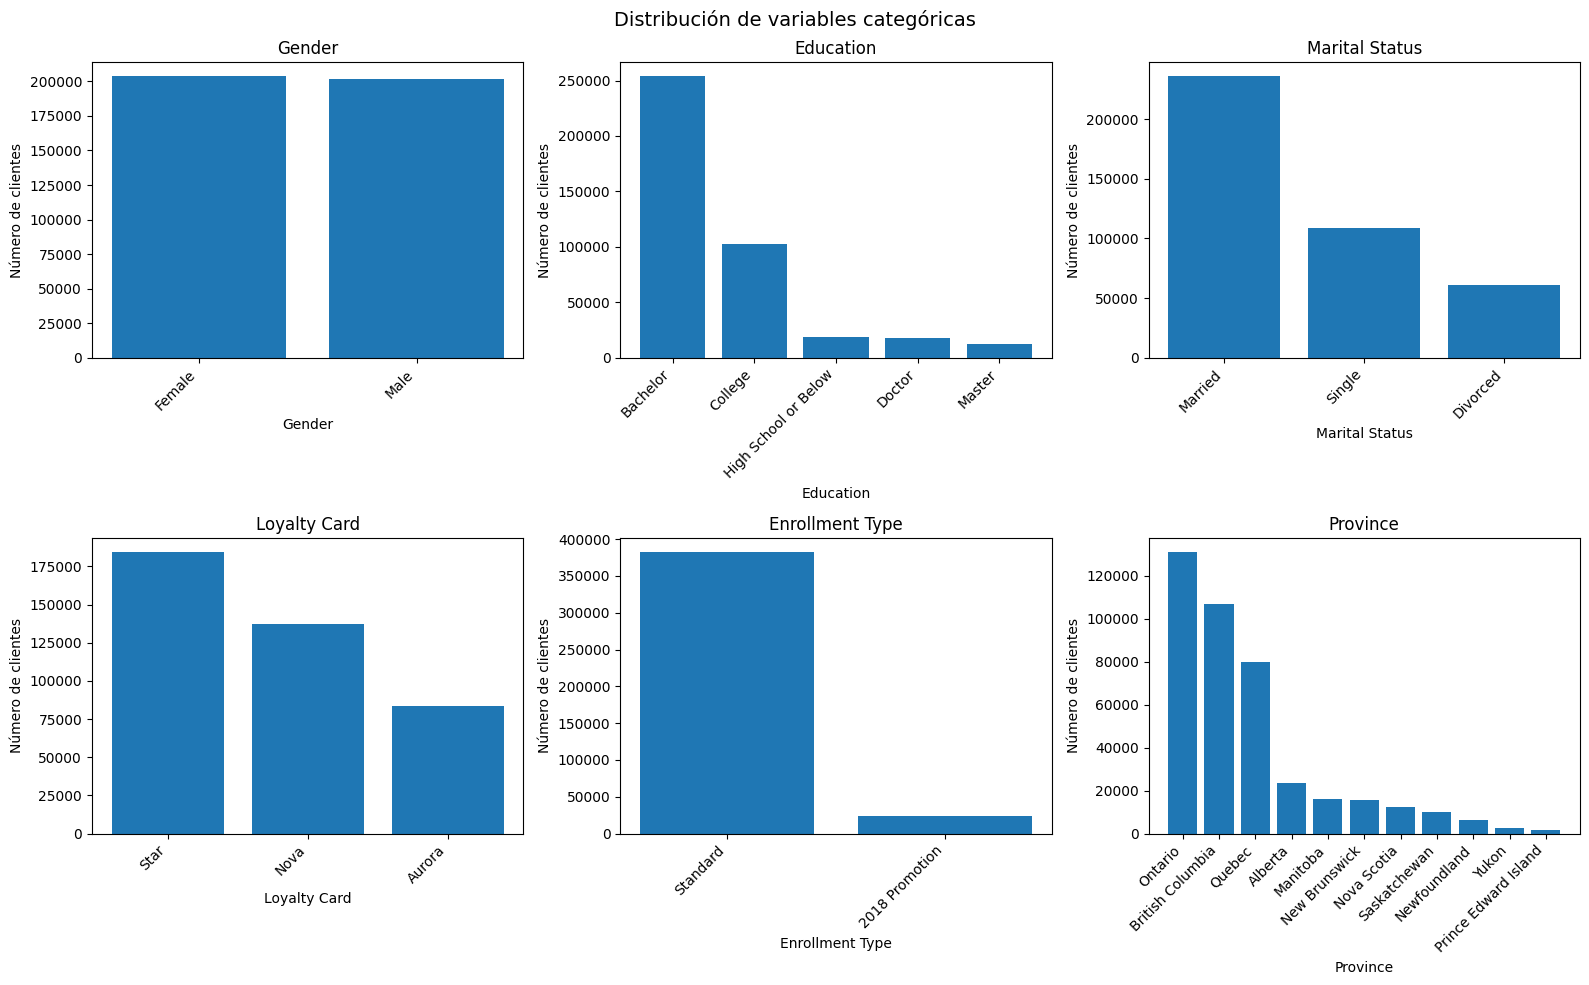

In [ ]:
variables_categoricas_graficos = ['Gender', 'Education', 'Marital Status', 'Loyalty Card', 'Enrollment Type', 'Province']

# Visualizamos la distribución de cada variable categórica con un barplot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten() # convertimos la matriz de ejes en una lista para iterar fácilmente

for i, var in enumerate(variables_categoricas_graficos):
    frecuencias = df[var].value_counts()                # ordenado de mayor a menor por defecto
    axes[i].bar(frecuencias.index, frecuencias.values)  # barplot con matplotlib
    axes[i].set_title(var)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Número de clientes")
    axes[i].tick_params(axis='x', rotation=45)           # rotamos etiquetas para que no se solapen
    plt.setp(axes[i].get_xticklabels(), ha='right')      # alineamos a la derecha para mejor lectura, especialmente necesario en Province por los nombres largos.

plt.suptitle("Distribución de variables categóricas", fontsize=14)
plt.tight_layout()
plt.show()

***
**Conclusiones – Variables categóricas:**

- **Gender**: la distribución es prácticamente equitativa, con un 50.2% de mujeres y un 49.8% 
de hombres. El programa de lealtad no muestra preferencia por ningún género.

- **Education**: la gran mayoría de clientes tiene estudios universitarios — Bachelor (62.56%) 
y College (25.31%) suman casi el 88% del total. Los niveles de Master, Doctor y estudios 
básicos son minoritarios, lo que apunta a un perfil de cliente con nivel educativo medio-alto.

- **Marital Status**: más de la mitad de los clientes son casados (58.13%), seguidos de 
solteros (26.79%) y divorciados (15.08%).

- **Loyalty Card**: la tarjeta Star es la más común (45.42%), seguida de Nova (33.92%) y 
Aurora (20.67%). La distribución es escalonada — Star casi dobla a Aurora, lo cual es típico 
en programas de lealtad con niveles. La mayoría de clientes se encuentra en el nivel base, 
lo que podría indicar una oportunidad para incentivar el ascenso a niveles superiores.

- **Enrollment Type**: el 94.23% de los clientes se inscribió de forma estándar. La promoción 
de 2018 solo captó un 5.77% del total, lo que sugiere que tuvo un impacto limitado.

- **Province**: Ontario (32.27%), British Columbia (26.34%) y Quebec (19.71%) concentran 
casi el 80% de los clientes. Esta distribución refleja la densidad de población real de Canadá, 
donde estas tres provincias son las más pobladas. El resto de provincias tienen una 
representación muy pequeña.

- **City**: se descartó del gráfico por tener 29 ciudades con valores muy dispersos (la mayoría 
entre 1-3%), lo que haría el gráfico ilegible. Los datos muestran que Toronto (19.99%), 
Vancouver (15.41%) y Montreal (12.31%) concentran casi la mitad del total de clientes, 
coincidiendo con las ciudades más pobladas de las tres provincias principales.
***

### **Fase 3: Visualización**
Usando las herramientas de visualización que has aprendido durante este módulo, contesta a las siguientes
preguntas usando la mejor gráfica que consideres:

1. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?
2. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?
3. ¿Cuál es la distribución de los clientes por provincia o estado?
4. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?
5. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?
6. ¿Cómo se distribuyen los clientes según su estado civil y género?

En todos los ejercicios, no te quedes solo con la representación visual: añade siempre una breve
interpretación en lenguaje natural, como lo haría un analista al presentar resultados a un equipo no
técnico.

*1. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?*

2. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?

*3. ¿Cuál es la distribución de los clientes por provincia o estado?*

*4. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?*

*5. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?*


*6. ¿Cómo se distribuyen los clientes según su estado civil y género?*

### **Fase 4: Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo**
Utilizando un conjunto de datos que hemos compartido, se busca evaluar si existen diferencias significativas en el número de vuelos reservados según el nivel educativo de los clientes. Para ello, los pasos que deberás seguir son:

1. **Preparación de Datos**: Filtra el conjunto de datos para incluir únicamente las columnas relevantes:
'Flights Booked' y 'Education'.
2. **Análisis Descriptivo**: Agrupa los datos por nivel educativo y calcula estadísticas descriptivas
básicas (como el promedio, la desviación estándar) del número de vuelos reservados para cada
grupo.